<a href="https://colab.research.google.com/github/yusrpro9/radar/blob/main/notebooks/preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preprocessing

This notebook performs exploratory data analysis (EDA) on the PAN-2026 and RAID datasets, then assembles the final **train / val / test** splits that will be consumed by the training notebook (`RADAR.ipynb`).

**Inputs (HuggingFace Hub)**
- `username/pan26` — official PAN-2026 task data (train / validation)
- `username/raid-dataset` — pre-filtered RAID subsets (dev / test)

**Outputs (local JSONL)**
- `data/pan26/train.jsonl` — processed PAN-2026 training set
- `data/pan26/val.jsonl` — processed PAN-2026 validation set  
- `data/raid/dev.jsonl` — balanced RAID development sample
- `data/raid/test.jsonl` — balanced RAID test sample

## Setup

In [ ]:
%%writefile requirements.txt
datasets==4.0.0
huggingface_hub==1.11.0
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
tqdm==4.67.3

Overwriting requirements.txt


In [ ]:
!pip install -r /content/requirements.txt --quiet

## Imports

In [ ]:
import logging
from tqdm.auto import tqdm
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datasets

## Configuration

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from huggingface_hub import login
from google.colab import userdata

HF_TOKEN = userdata.get('HF_TOKEN')
HF_USERNAME = userdata.get('HF_USERNAME')
login(token=HF_TOKEN)

In [ ]:
from pathlib import Path
import torch

class CFG:
    PROJECT_DIR: Path = Path("/content/drive/MyDrive/robust-ai-text-detector")
    DATA_DIR: Path = PROJECT_DIR / "data"
    DATA_TRAIN: Path = DATA_DIR / "pan26" / "train.jsonl"
    DATA_VAL: Path = DATA_DIR / "pan26" / "val.jsonl"
    DATA_DEV: Path = DATA_DIR / "raid" / "dev.jsonl"
    DATA_TEST: Path = DATA_DIR / "raid" / "test.jsonl"
    OUTPUT_DIR: Path = PROJECT_DIR / "outputs"
    ID2LABEL: dict = {0: "human", 1: "machine"}
    LABEL2ID: dict = {"human": 0, "machine": 1}
    RANDOM_SEED: int = 42
    RAID_TRAIN_SAMPLE: int = 30_000
    RAID_TEST_SAMPLE: int = 10_000

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Loading Data

Load PAN-2026 from the HuggingFace Hub.

In [ ]:
pan26_ds = datasets.load_dataset(f"{HF_USERNAME}/pan26")
train_df = pan26_ds['train'].to_pandas()
val_df = pan26_ds['validation'].to_pandas()

README.md:   0%|          | 0.00/529 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/56.7M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/8.42M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/23707 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3589 [00:00<?, ? examples/s]

Load the pre-filtered RAID subsets (prepared by `datasets_preparation.ipynb`).

In [ ]:
raid_ds = datasets.load_dataset(f"{HF_USERNAME}/raid-dataset")
dev_df = raid_ds['dev'].to_pandas()
test_df = raid_ds['test'].to_pandas()


README.md:   0%|          | 0.00/695 [00:00<?, ?B/s]

data/dev-00000-of-00002.parquet:   0%|          | 0.00/287M [00:00<?, ?B/s]

data/dev-00001-of-00002.parquet:   0%|          | 0.00/287M [00:00<?, ?B/s]

data/test-00000-of-00002.parquet:   0%|          | 0.00/192M [00:00<?, ?B/s]

data/test-00001-of-00002.parquet:   0%|          | 0.00/191M [00:00<?, ?B/s]

Generating dev split:   0%|          | 0/559860 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/373240 [00:00<?, ? examples/s]

In [ ]:
print(f"PAN-2026 train : {len(train_df):>7,} rows")
print(f"PAN-2026 val   : {len(val_df):>7,} rows")
print(f"RAID dev       : {len(dev_df):>7,} rows")
print(f"RAID test      : {len(test_df):>7,} rows")

PAN-2026 train :  23,707 rows
PAN-2026 val   :   3,589 rows
RAID dev       : 559,860 rows
RAID test      : 373,240 rows


## Exploratory Data Analysis

### PAN-2026 Dataset

**Schema and basic statistics**

In [ ]:
train_df.info()
train_df.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23707 entries, 0 to 23706
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      23707 non-null  object
 1   text    23707 non-null  object
 2   model   23707 non-null  object
 3   label   23707 non-null  int64 
 4   genre   23707 non-null  object
dtypes: int64(1), object(4)
memory usage: 926.2+ KB


,id,text,model,label,genre
0,ea468d03-1973-5039-86b2-ff225bb92c4e,"Duke Ellington, a titan of jazz, revolutionize...",falcon3-10b-instruct,1,essays
1,0d05f269-6d67-521d-9b5d-cc18f482c6c1,I reflected on the shifting dynamics of media ...,o3-mini,1,essays
2,c2ec79f3-da80-58f8-bef0-3e0ea7ab072f,"In F. Scott Fitzgerald's ""The Great Gatsby,"" t...",gpt-4o,1,essays


**Label distribution**

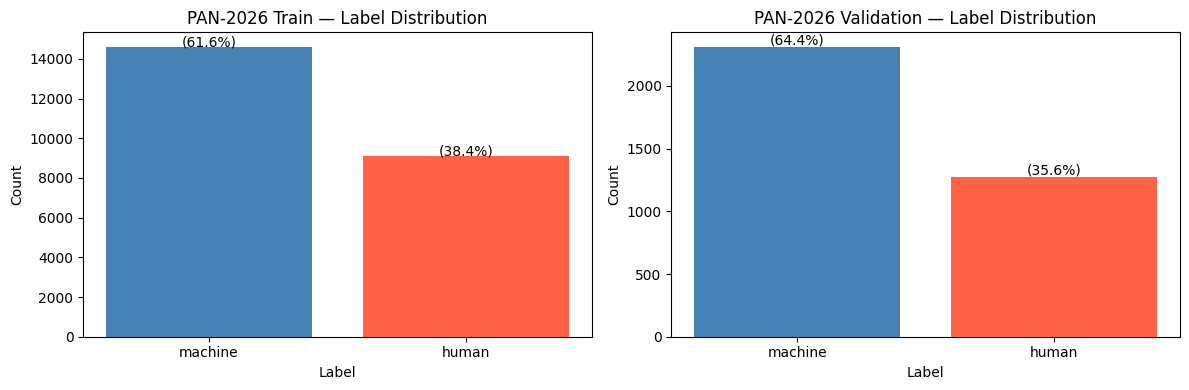

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, df, title in zip(axes, [train_df, val_df], ['Train', 'Validation']):
    counts = df['label'].map(CFG.ID2LABEL).value_counts()
    ax.bar(counts.index, counts.values, color=['steelblue', 'tomato'])
    ax.set_title(f'PAN-2026 {title} — Label Distribution')
    ax.set_xlabel('Label')
    ax.set_ylabel('Count')
    for j, (lbl, cnt) in enumerate(counts.items()):
        ax.text(j, cnt + 20, f'({cnt/len(df)*100:.1f}%)', ha='center')

plt.tight_layout()
plt.show()

**Genre distribution**

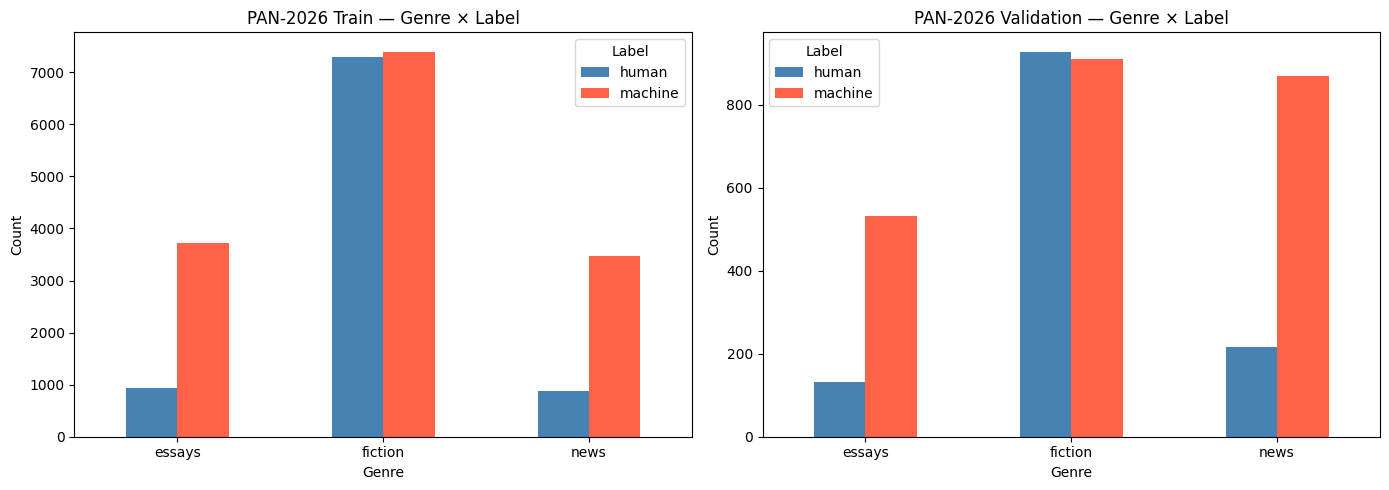

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title in zip(axes, [train_df, val_df], ['Train', 'Validation']):
    genre_label = df.groupby(['genre', df['label'].map(CFG.ID2LABEL)]).size().unstack(fill_value=0)
    genre_label.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
    ax.set_title(f'PAN-2026 {title} — Genre × Label')
    ax.set_xlabel('Genre')
    ax.set_ylabel('Count')
    ax.legend(title='Label')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**AI model distribution (training)**

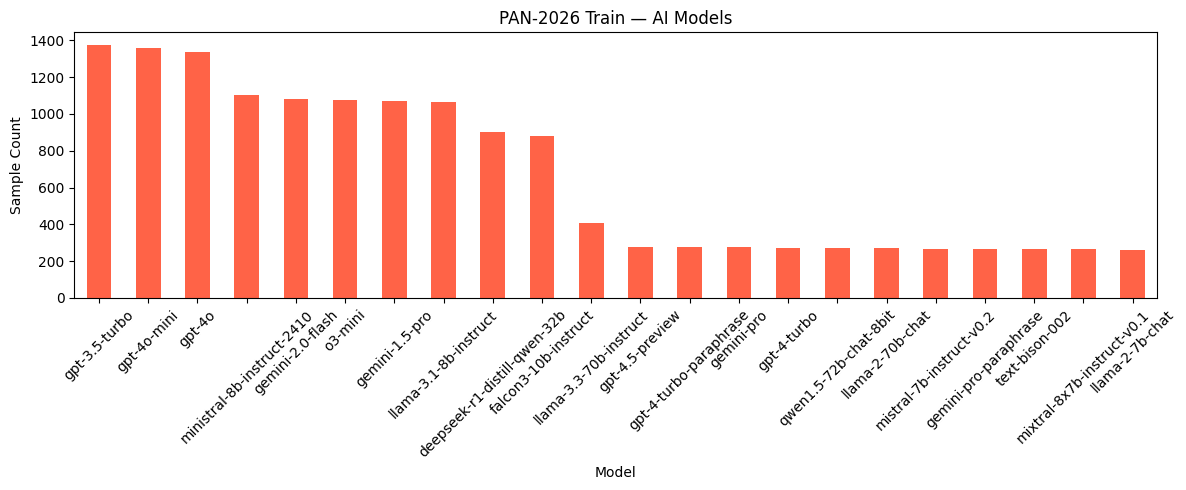

In [ ]:
model_counts = train_df[train_df['label'] == 1]['model'].value_counts()
fig, ax = plt.subplots(figsize=(12, 5))
model_counts.plot(kind='bar', ax=ax, color='tomato')
ax.set_title('PAN-2026 Train — AI Models')
ax.set_xlabel('Model')
ax.set_ylabel('Sample Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Text length distribution**

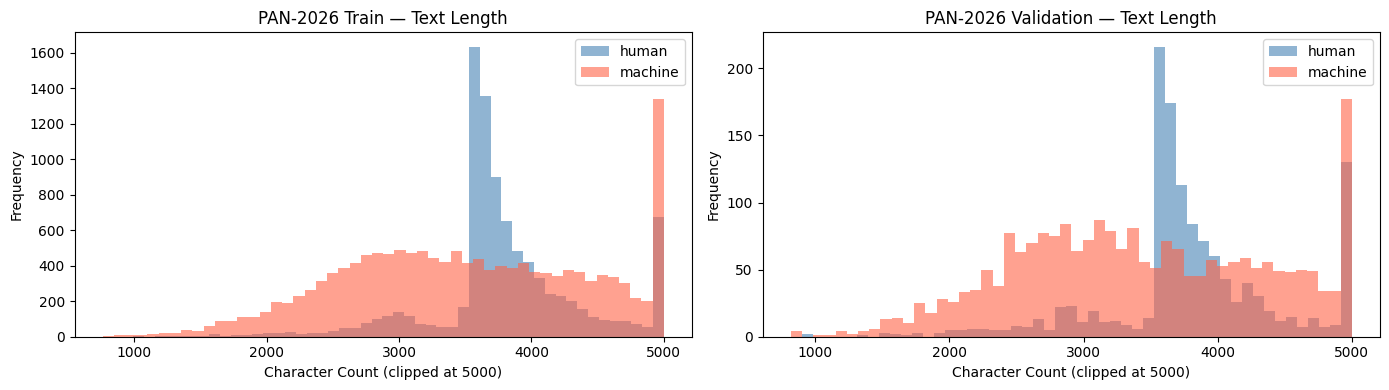

In [ ]:
for df, name in [(train_df, 'Train'), (val_df, 'Validation')]:
    df['text_len'] = df['text'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, df, title in zip(axes, [train_df, val_df], ['Train', 'Validation']):
    for lbl, color in [(0, 'steelblue'), (1, 'tomato')]:
        subset = df[df['label'] == lbl]['text_len']
        ax.hist(subset.clip(0, 5000), bins=50, alpha=0.6,
                color=color, label=CFG.ID2LABEL[lbl])
    ax.set_title(f'PAN-2026 {title} — Text Length')
    ax.set_xlabel('Character Count (clipped at 5000)')
    ax.set_ylabel('Frequency')
    ax.legend()
plt.tight_layout()
plt.show()

### RAID Dataset

**Schema and basic statistics**

In [ ]:
dev_df.info()
dev_df.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 559860 entries, 0 to 559859
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             559860 non-null  object
 1   adv_source_id  559860 non-null  object
 2   source_id      559860 non-null  object
 3   text           559860 non-null  object
 4   model          559860 non-null  object
 5   attack         559860 non-null  object
 6   genre          559860 non-null  object
 7   label          559860 non-null  int64 
dtypes: int64(1), object(7)
memory usage: 34.2+ MB


,id,adv_source_id,source_id,text,model,attack,genre,label
0,db2a9624-9532-463b-b331-0ae86b52091b,db2a9624-9532-463b-b331-0ae86b52091b,b47ec949-0c37-4320-8f13-bcfdeb0f466e,The Conservatives have attacked plans to allow...,mistral,none,news,1
1,39035d74-7b5b-4e35-b272-0753b12f89db,39035d74-7b5b-4e35-b272-0753b12f89db,047fd9c7-bd71-4595-9111-bd5c4b6a4030,"In the small town of Ashwood, a sense of uneas...",llama-chat,none,books,1
2,cd35f3cd-ff98-4cfe-b7f1-12abbd5baeb7,cd35f3cd-ff98-4cfe-b7f1-12abbd5baeb7,083a11a3-11e8-4cf1-b680-2b282012cfb4,"In one corner, we have what most Internet user...",mistral,none,news,1


**Label distribution**

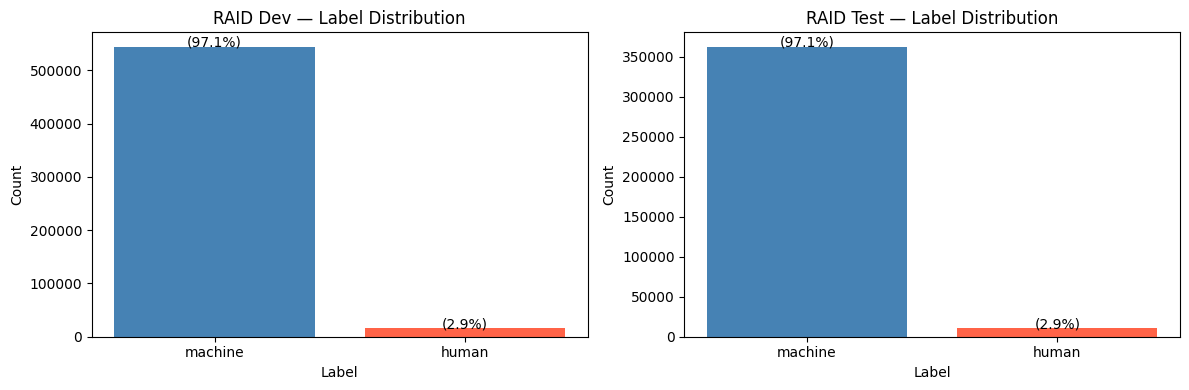

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, df, title in zip(axes, [dev_df, test_df], ['Dev', 'Test']):
    counts = df['label'].map(CFG.ID2LABEL).value_counts()
    ax.bar(counts.index, counts.values, color=['steelblue', 'tomato'])
    ax.set_title(f'RAID {title} — Label Distribution')
    ax.set_xlabel('Label')
    ax.set_ylabel('Count')
    for j, (lbl, cnt) in enumerate(counts.items()):
        ax.text(j, cnt + 20, f'({cnt/len(df)*100:.1f}%)', ha='center')
plt.tight_layout()
plt.show()

**Attack-type distribution in RAID dev**

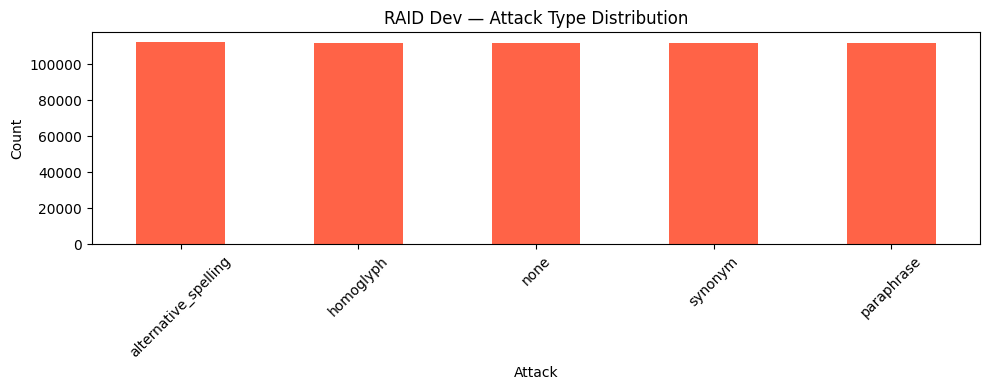

In [ ]:
attack_counts = dev_df['attack'].value_counts()
fig, ax = plt.subplots(figsize=(10, 4))
attack_counts.plot(kind='bar', ax=ax, color='tomato')
ax.set_title('RAID Dev — Attack Type Distribution')
ax.set_xlabel('Attack')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Genre distribution in RAID dev**

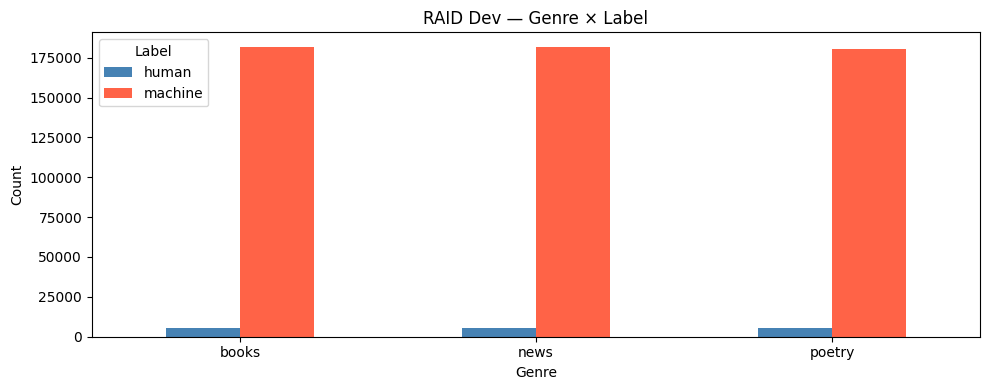

In [ ]:
genre_label = dev_df.groupby(['genre', dev_df['label'].map(CFG.ID2LABEL)]).size().unstack(fill_value=0)
genre_label.plot(kind='bar', figsize=(10, 4), color=['steelblue', 'tomato'])
plt.title('RAID Dev — Genre × Label')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Label')
plt.tight_layout()
plt.show()

## Data Issues and Decisions

After the EDA, three structural issues require attention before training:

| Issue | Observation | Decision |
|-------|-------------|----------|
| **Class imbalance (PAN-2026)** | 61.6 % AI vs 38.4 % Human in training | Apply class-weighted loss during training (`w_human ≈ 1.6`) |
| **Genre imbalance (PAN-2026)** | Fiction dominates at 61.9 % | Retain all data; address via stratified batching in the trainer |
| **RAID size disparity** | 559 K dev rows vs 23 K PAN-2026 train rows | Down-sample RAID to `CFG.RAID_TRAIN_SAMPLE` (30 K) balanced rows for augmentation |
| **RAID test for OOD evaluation** | 373 K rows is unnecessary for validation | Down-sample RAID test to `CFG.RAID_TEST_SAMPLE` (10 K) balanced rows |

**RAID sampling strategy:** stratified random sampling per (label, genre, attack) cell, then global balance to 50 % human / 50 % AI. This preserves the diversity of attacks and genres in the smaller sample.

## Data Preprocessing

Define a lightweight text normalizer that removes PII patterns (email, phone, user mentions).

In [ ]:
import re

_EMAIL_RE = re.compile(r'(?i)\b[A-Z0-9._%+-]+@[A-Z0-9.-]+\.[A-Z]{2,}\b')
_USER_RE  = re.compile(r'@[A-Za-z0-9_-]+')
_PHONE_RE = re.compile(
    r'(\+?\d{1,3})?[\s\*\.\-]?\(?\d{1,4}\)?[\s\*\.\-]?\d{2,4}[\s\*\.\-]?\d{2,6}'
)

def preprocess(text: str) -> str:
    text = _EMAIL_RE.sub('[EMAIL]', text)
    text = _USER_RE.sub('[USER]', text)
    text = _PHONE_RE.sub(' [PHONE]', text).replace('  [PHONE]', ' [PHONE]')
    return text.lower().strip()


Apply preprocessing to both PAN-2026 splits.

In [ ]:
train_df['text'] = train_df['text'].map(preprocess)
val_df['text'] = val_df['text'].map(preprocess)

train_df.drop_duplicates(subset=['text'], inplace=True, ignore_index=True)
train_df.dropna(subset=['text'], inplace=True)
train_df = train_df[train_df['text'].str.len() >= 50].reset_index(drop=True)

print(f"PAN-2026 train after dedup/filter: {len(train_df):,} rows")

PAN-2026 train after dedup/filter: 23,682 rows


## RAID Sampling

Draw a stratified balanced sample from the RAID dev and test splits.

The sample is balanced at **50 % human / 50 % AI** to provide a challenging and unbiased training signal. Stratification over `(label, genre, attack)` ensures all attack types are represented proportionally.

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

def balanced_sample(df: pd.DataFrame, n: int, seed: int = 42) -> pd.DataFrame:
    half = n // 2
    human = df[df['label'] == 0].sample(n=min(half, (df['label'] == 0).sum()), random_state=seed)
    machine = df[df['label'] == 1].sample(n=min(half, (df['label'] == 1).sum()), random_state=seed)
    return pd.concat([human, machine]).sample(frac=1, random_state=seed).reset_index(drop=True)

dev_sample = balanced_sample(dev_df, CFG.RAID_TRAIN_SAMPLE, seed=CFG.RANDOM_SEED)
test_sample = balanced_sample(test_df, CFG.RAID_TEST_SAMPLE, seed=CFG.RANDOM_SEED)

print(f"RAID dev sample  : {len(dev_sample):,} rows  "
      f"(human={( dev_sample['label']==0).sum():,}, machine={(dev_sample['label']==1).sum():,})")
print(f"RAID test sample : {len(test_sample):,} rows  "
      f"(human={(test_sample['label']==0).sum():,}, machine={(test_sample['label']==1).sum():,})")

RAID dev sample  : 30,000 rows  (human=15,000, machine=15,000)
RAID test sample : 10,000 rows  (human=5,000, machine=5,000)


Verify attack-type coverage in the sample.

In [ ]:
dev_sample['attack'].value_counts()

,count
attack,
synonym,6048
paraphrase,6025
alternative_spelling,6008
none,5997
homoglyph,5922


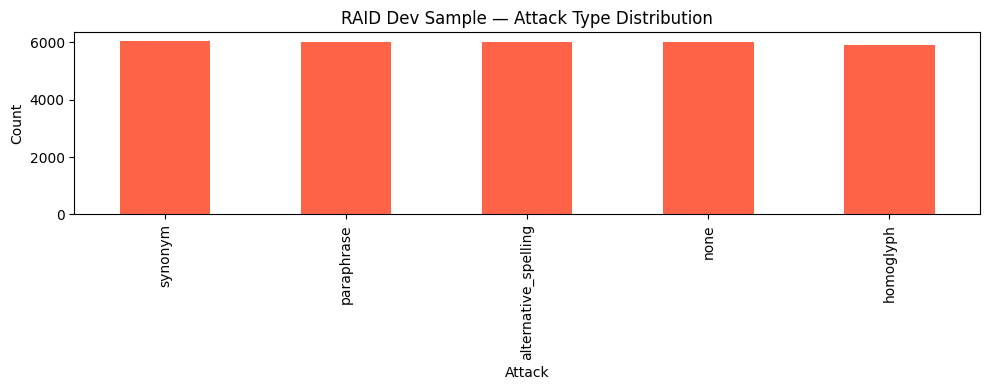

In [ ]:
dev_sample['attack'].value_counts().plot(kind='bar', figsize=(10, 4), color='tomato')
plt.title('RAID Dev Sample — Attack Type Distribution')
plt.xlabel('Attack')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
test_sample['attack'].value_counts()

,count
attack,
alternative_spelling,2037
paraphrase,2034
synonym,2008
none,1969
homoglyph,1952


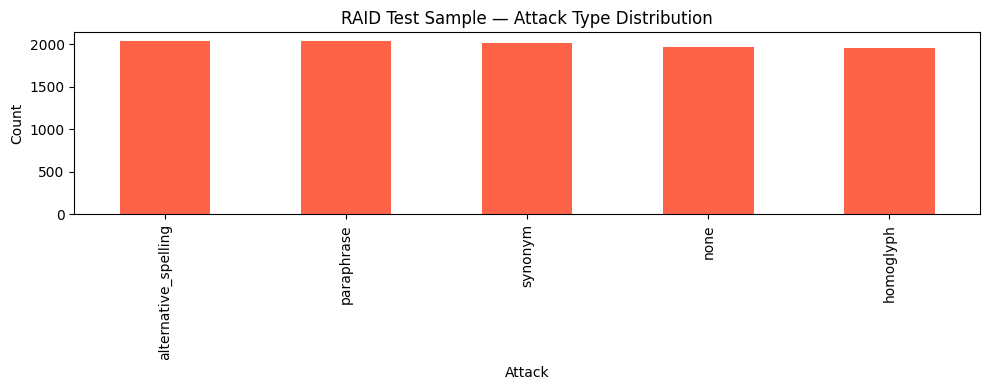

In [ ]:
test_sample['attack'].value_counts().plot(kind='bar', figsize=(10, 4), color='tomato')
plt.title('RAID Test Sample — Attack Type Distribution')
plt.xlabel('Attack')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Apply the same preprocessing to RAID samples.

In [ ]:
dev_sample['text'] = dev_sample['text'].map(preprocess)
test_sample['text'] = test_sample['text'].map(preprocess)

## Final Split Overview

Compute per-split statistics to verify balance before saving.

In [ ]:
splits = {
    'pan26/train': train_df,
    'pan26/val':   val_df,
    'raid/dev':    dev_sample,
    'raid/test':   test_sample,
}

rows = []
for name, df in splits.items():
    human   = (df['label'] == 0).sum()
    machine = (df['label'] == 1).sum()
    rows.append({'Split': name, 'Total': len(df),
                 'Human': human, 'Machine': machine,
                 'Human %': f'{100*human/len(df):.1f}',
                 'Machine %': f'{100*machine/len(df):.1f}'})

pd.DataFrame(rows)

,Split,Total,Human,Machine,Human %,Machine %
0,pan26/train,23682,9076,14606,38.3,61.7
1,pan26/val,3589,1277,2312,35.6,64.4
2,raid/dev,30000,15000,15000,50.0,50.0
3,raid/test,10000,5000,5000,50.0,50.0


Label distribution comparison across splits.

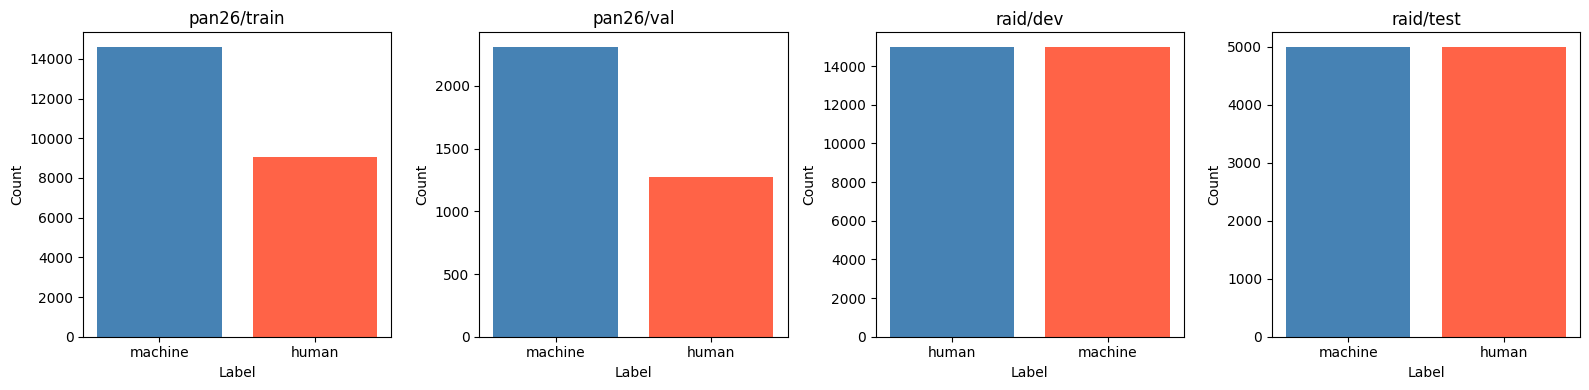

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, df) in zip(axes, splits.items()):
    counts = df['label'].map(CFG.ID2LABEL).value_counts()
    ax.bar(counts.index, counts.values, color=['steelblue', 'tomato'])
    ax.set_title(name)
    ax.set_xlabel('Label')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## Save Final Splits

Persist the final processed splits as JSONL for offline use in `RADAR.ipynb`.

In [ ]:
COLUMNS = ['id', 'text', 'label', 'model', 'genre']

def save_jsonl(df: pd.DataFrame, path: Path, columns) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    cols = [c for c in columns if c in df.columns]
    df[cols].to_json(path, orient='records', lines=True, force_ascii=False)

save_jsonl(train_df,   CFG.DATA_TRAIN, COLUMNS)
save_jsonl(val_df,     CFG.DATA_VAL,   COLUMNS)
save_jsonl(dev_sample, CFG.DATA_DEV,   COLUMNS + ['attack'])
save_jsonl(test_sample,CFG.DATA_TEST,  COLUMNS + ['attack'])

for name, path in [('pan26/train', CFG.DATA_TRAIN), ('pan26/val', CFG.DATA_VAL),
                    ('raid/dev', CFG.DATA_DEV), ('raid/test', CFG.DATA_TEST)]:
    n = sum(1 for _ in open(path))
    print(f'{name:15s} -> {path.name}  ({n:,} lines)')

pan26/train     -> train.jsonl  (23,682 lines)
pan26/val       -> val.jsonl  (3,589 lines)
raid/dev        -> dev.jsonl  (30,000 lines)
raid/test       -> test.jsonl  (10,000 lines)


In [ ]:
pan26_raid_ds = datasets.DatasetDict({
    'train': datasets.Dataset.from_json(str(CFG.DATA_TRAIN)),
    'validation': datasets.Dataset.from_json(str(CFG.DATA_VAL)),
    'dev': datasets.Dataset.from_json(str(CFG.DATA_DEV)),
    'test': datasets.Dataset.from_json(str(CFG.DATA_TEST)),
})
pan26_raid_ds

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'label', 'model', 'genre'],
        num_rows: 23682
    })
    validation: Dataset({
        features: ['id', 'text', 'label', 'model', 'genre'],
        num_rows: 3589
    })
    dev: Dataset({
        features: ['id', 'text', 'label', 'model', 'genre', 'attack'],
        num_rows: 30000
    })
    test: Dataset({
        features: ['id', 'text', 'label', 'model', 'genre', 'attack'],
        num_rows: 10000
    })
})

In [ ]:
pan26_raid_ds['train'].push_to_hub(f"{HF_USERNAME}/pan26-raid",config_name="pan26",split="train")
pan26_raid_ds['validation'].push_to_hub(f"{HF_USERNAME}/pan26-raid",config_name="pan26",split="validation")

In [ ]:
pan26_raid_ds['dev'].push_to_hub(f"{HF_USERNAME}/pan26-raid",config_name="raid",split="dev")
pan26_raid_ds['test'].push_to_hub(f"{HF_USERNAME}/pan26-raid",config_name="raid",split="test")

## Summary

### What this notebook does

1. **Loads** PAN-2026 (23,707 train / 3,589 val) and RAID (559,860 dev / 373,240 test) datasets.
2. **Analyzes** label balance, genre distribution, model coverage, attack types, and text-length profiles.
3. **Preprocesses** all texts: lowercasing, PII masking (email / phone / user-mention), deduplication, and minimum-length filtering (≥ 50 chars).
4. **Samples** RAID:
   - Dev: 30,000 rows (15 K human + 15 K AI, stratified)
   - Test: 10,000 rows (5 K human + 5 K AI, stratified)
5. **Saves** four JSONL files that are loaded directly by `RADAR.ipynb`.

### Key decisions and rationale

| Decision | Rationale |
|----------|-----------|
| Keep PAN-2026 train / val separate from RAID | PAN-2026 val is the *official* evaluation split; it must not be contaminated by external data to allow fair comparison with the competition baselines |
| Balance RAID sample 50/50 | PAN-2026 already introduces the 61.6 % AI skew; RAID augmentation should not amplify this further — balanced external data acts as a regulariser |
| Down-sample RAID to 30 K / 10 K | The raw RAID files are 100× larger than PAN-2026 train; training on the full set would bias the model toward RAID's domain distribution |
| Lowercase + PII masking | Reduces surface noise; prevents the model from using email/phone tokens as identity signals |
| Deduplication on text | Prevents exact-match memorisation that could inflate validation metrics |

### Final split statistics

| Split | Rows | Human | Machine | Source |
|-------|------|-------|---------|--------|
| pan26/train | ~23,700 | ~9,100 (38 %) | ~14,600 (62 %) | PAN-2026 official |
| pan26/val   | 3,589   | ~1,277 (36 %) | ~2,312 (64 %)  | PAN-2026 official |
| raid/dev    | 30,000  | 15,000 (50 %) | 15,000 (50 %)  | RAID (sampled) |
| raid/test   | 10,000  | 5,000 (50 %)  | 5,000 (50 %)   | RAID (sampled) |

### How these splits are used in training

- **`pan26/train` + `raid/dev`** — concatenated as the combined training set in `RADAR.ipynb`; the trainer applies 62:38 class weights derived from the PAN-2026 train distribution.
- **`pan26/val`** — primary validation during training; used for early stopping and learning-rate scheduling.
- **`raid/test`** — out-of-domain evaluation; used for model selection (best checkpoint = 0.6 × PAN val score + 0.4 × RAID test score).